ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


2. CARGA DEL DATASET


README.md: 0.00B [00:00, ?B/s]

Patient1.csv:   0%|          | 0.00/114M [00:00<?, ?B/s]

Patient2.csv:   0%|          | 0.00/290M [00:00<?, ?B/s]

...

Dimensiones originales del dataset: (3002137, 10)

Columnas:
['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target']

Primeras filas:


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0



3. ANÁLISIS PRELIMINAR Y PREPROCESAMIENTO

Clasificación de variables:


,Variable,Tipo de variable
0,Time,Numérica continua (tiempo)
1,Right Rectus femoris,Numérica continua (señal EMG)
2,Left Gluteus maximus,Numérica continua (señal EMG)
3,Left Gastrocnemius medialis,Numérica continua (señal EMG)
4,Left Semitendinosus,Numérica continua (señal EMG)
5,Left Biceps femoris caput longus,Numérica continua (señal EMG)
6,Right Vastus medialis,Numérica continua (señal EMG)
7,Right Tibialis anterior,Numérica continua (señal EMG)
8,Left Gastrocnemius lateralis,Numérica continua (señal EMG)
9,Target,Binaria / categórica objetivo



Distribución del target después del preprocesamiento:
Target
0    2127600
1     874537
Name: count, dtype: int64

INTERPRETACIÓN:
- Este es un problema de clasificación supervisada binaria.
- La variable objetivo es Target, donde 0 = condición normal y 1 = desgaste muscular.
- Las 8 señales EMG son variables numéricas continuas.
- Time es una variable temporal continua, pero NO se usará en la base final de características
  porque el enunciado indica que su dependencia lineal con el target podría simplificar en exceso el problema.

4. FRECUENCIA DE MUESTREO Y DISEÑO DE VENTANAS
Diferencia temporal mediana entre muestras (dt): 0.001000 s
Frecuencia de muestreo estimada (fs): 1000 Hz
Tamaño de ventana para 1 segundo: 1000 muestras

INTERPRETACIÓN:
- Se calcula la frecuencia de muestreo a partir de la columna Time.
- Como dt ≈ 0.001 s, entonces fs ≈ 1000 Hz.
- Por tanto, una ventana de 1 segundo corresponde a 1000 muestras.
- Esto justifica formalmente el uso de window_size = 1000, en lu

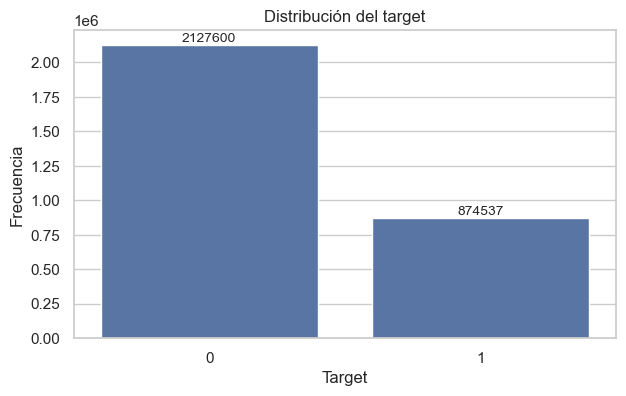

Porcentaje por clase:
Target
0    70.869517
1    29.130483
Name: proportion, dtype: float64

INTERPRETACIÓN DEL BALANCE DE CLASES:
- Existe desbalance de clases: la clase 0 (normal) aparece con mayor frecuencia que la clase 1 (fatiga).
- Esto es importante porque un modelo podría obtener buena accuracy favoreciendo la clase mayoritaria.
- Por eso también se reportan Precision, Recall y F1-score, especialmente para la clase fatigada.

Estadísticos descriptivos generales:


,count,mean,std,min,25%,50%,75%,max
Time,3002137.0,6.385404e+02,485.515590,0.000000,250.178000,500.356000,991.064000,1741.598000
Right Rectus femoris,3002137.0,3.818719e-10,0.043227,-0.843342,-0.009713,0.000040,0.010189,0.992085
Left Gluteus maximus,3002137.0,-5.484116e-09,0.021263,-1.117295,-0.003885,-0.000015,0.003920,1.063230
Left Gastrocnemius medialis,3002137.0,1.607046e-08,0.046804,-1.749318,-0.008921,0.000098,0.009312,1.614778
Left Semitendinosus,3002137.0,6.232624e-09,0.032353,-1.575973,-0.006286,-0.000127,0.006089,0.868585
Left Biceps femoris caput longus,3002137.0,2.408926e-08,0.042564,-0.750301,-0.008236,0.000163,0.009009,0.842989
Right Vastus medialis,3002137.0,-2.482363e-08,0.071763,-1.216622,-0.009509,0.000119,0.011129,1.079527
Right Tibialis anterior,3002137.0,4.634169e-10,0.057024,-1.304432,-0.013326,-0.000150,0.013157,1.336625
Left Gastrocnemius lateralis,3002137.0,-5.008274e-08,0.059265,-1.199719,-0.013916,0.000650,0.016875,0.940051
Target,3002137.0,2.913048e-01,0.454364,0.000000,0.000000,0.000000,1.000000,1.000000


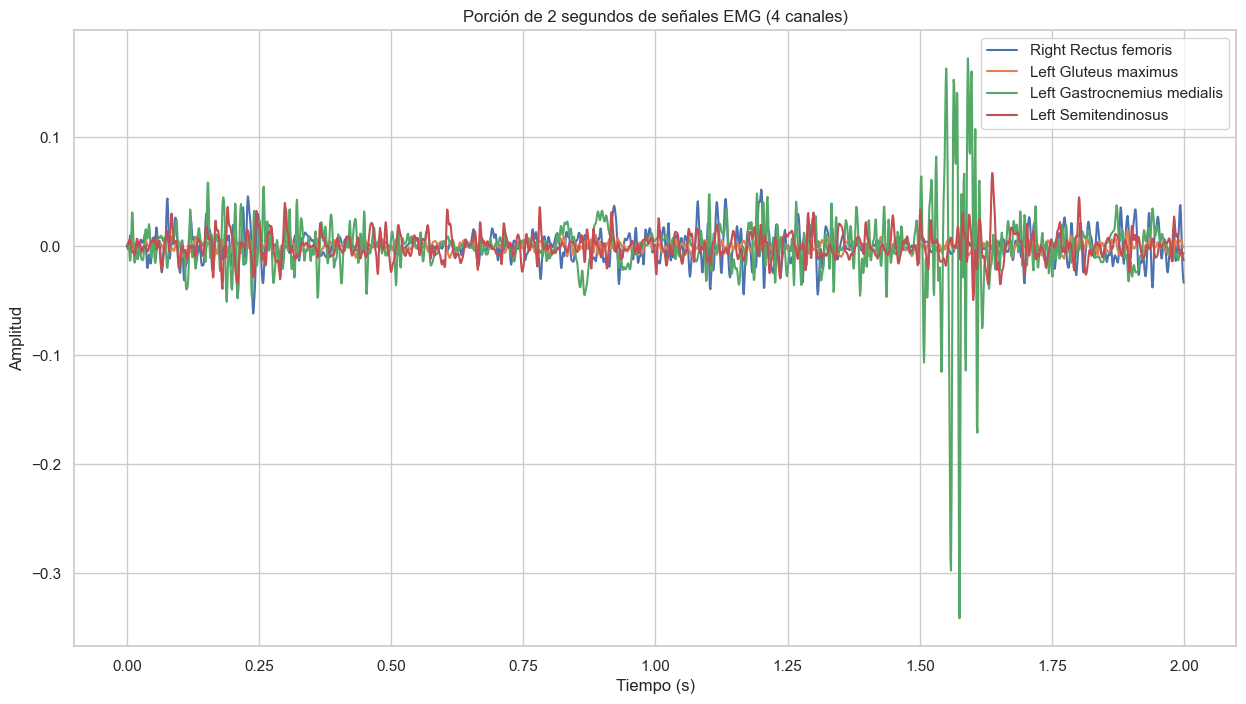

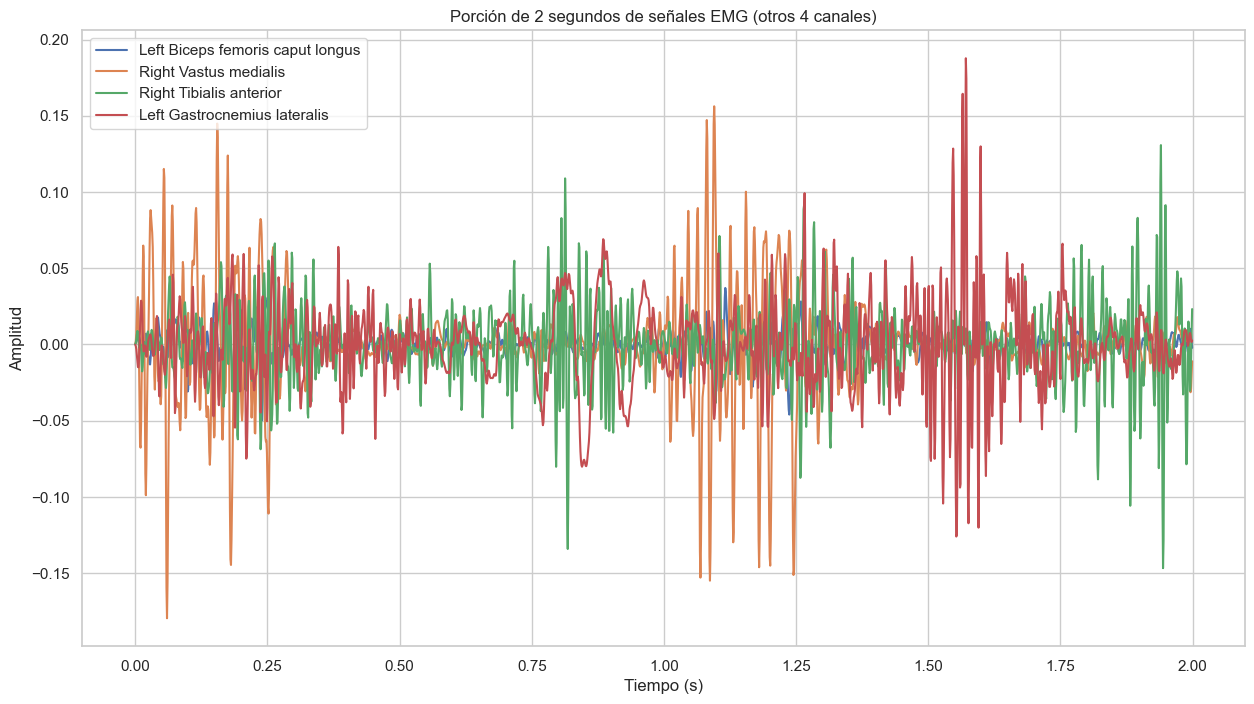

CONCLUSIONES INICIALES SOBRE EL DATASET:
- Las señales EMG presentan oscilaciones rápidas alrededor de cero, lo cual es consistente con señales musculares.
- La amplitud y variabilidad cambian entre músculos, por lo que cada canal puede aportar información distinta.
- Visualmente no es trivial separar fatiga vs normal directamente desde la señal cruda.
- Esto justifica hacer feature engineering, resumiendo la señal en características del dominio del tiempo y la frecuencia.


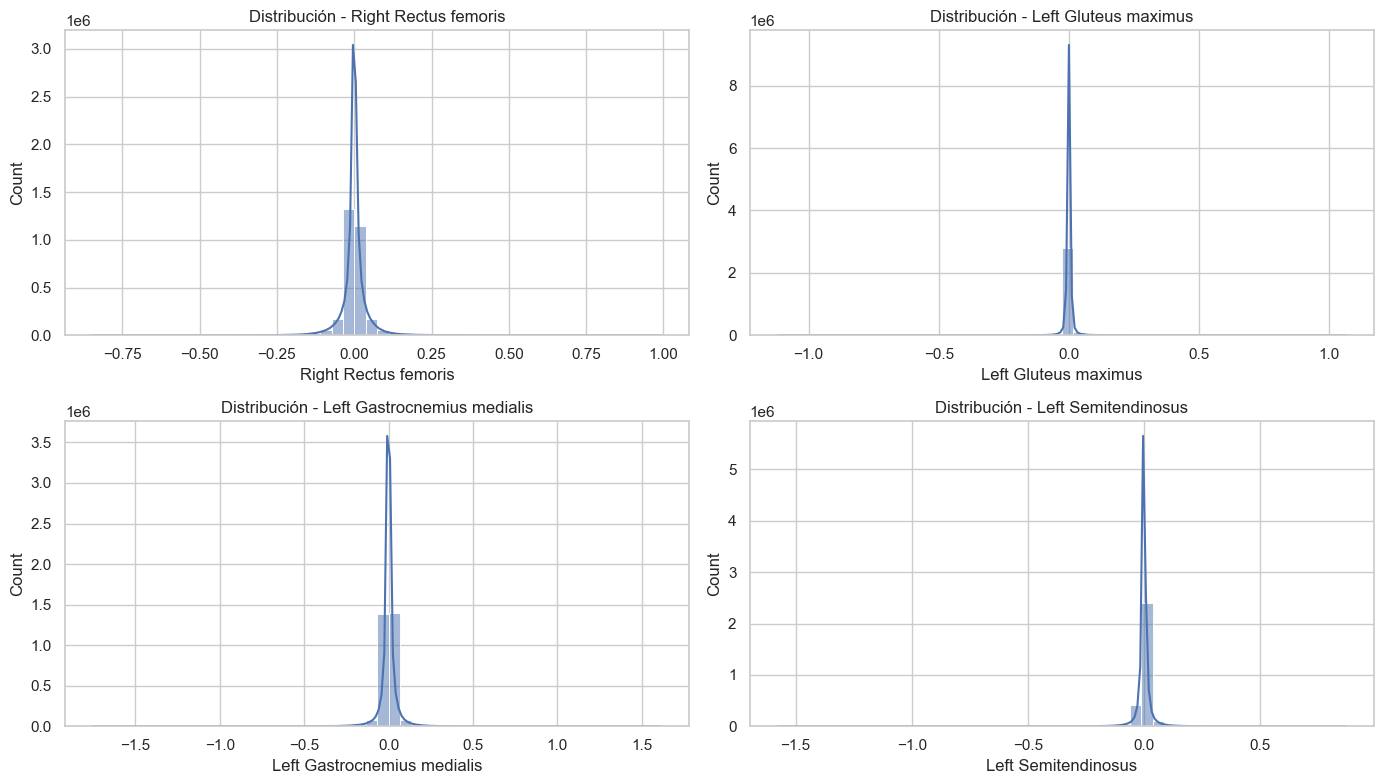

INTERPRETACIÓN DE DISTRIBUCIONES CRUDAS:
- Las señales están centradas cerca de cero, como es esperable en EMG.
- Hay colas y variabilidad diferentes entre músculos.
- Esto sugiere que la energía, dispersión y contenido frecuencial podrían ser útiles para detectar fatiga.

6. FEATURE ENGINEERING
JUSTIFICACIÓN DE LAS CARACTERÍSTICAS:
- RMS: mide la energía efectiva de la contracción muscular; la fatiga puede modificar su magnitud.
- Variance: refleja dispersión/amplitud de la señal; puede cambiar con el esfuerzo muscular.
- Zero crossings: resume oscilaciones y cambios de signo, relacionados con actividad neuromuscular.
- Mean slope: cuantifica qué tan brusca es la variación promedio de la señal.
- Mean frequency: permite detectar desplazamientos del contenido espectral.
- Median frequency: es una característica clásica en EMG, usada frecuentemente para estudiar fatiga muscular.

Dimensiones de la nueva base de características: (3002, 49)
Primeras filas de la nueva base:


,Right Rectus femoris_rms,Right Rectus femoris_variance,Right Rectus femoris_zero_crossings,Right Rectus femoris_mean_slope,Right Rectus femoris_mean_freq,Right Rectus femoris_median_freq,Left Gluteus maximus_rms,Left Gluteus maximus_variance,Left Gluteus maximus_zero_crossings,Left Gluteus maximus_mean_slope,...,Right Tibialis anterior_mean_slope,Right Tibialis anterior_mean_freq,Right Tibialis anterior_median_freq,Left Gastrocnemius lateralis_rms,Left Gastrocnemius lateralis_variance,Left Gastrocnemius lateralis_zero_crossings,Left Gastrocnemius lateralis_mean_slope,Left Gastrocnemius lateralis_mean_freq,Left Gastrocnemius lateralis_median_freq,target
0,0.011706,0.000137,123,0.003076,54.570839,50.78125,0.003989,0.000016,122,0.001235,...,0.010064,90.848194,93.75000,0.025655,0.000658,120,0.006508,59.538860,50.78125,0
1,0.014023,0.000197,111,0.003891,55.855995,54.68750,0.004223,0.000018,120,0.001359,...,0.010552,86.074709,82.03125,0.031409,0.000986,149,0.011270,79.432906,78.12500,0
2,0.014820,0.000220,121,0.003840,54.184637,46.87500,0.004209,0.000018,126,0.001311,...,0.010216,85.845206,85.93750,0.026209,0.000687,101,0.007284,58.352164,54.68750,0
3,0.013817,0.000191,121,0.003916,57.536178,46.87500,0.004374,0.000019,115,0.001371,...,0.010824,86.521514,85.93750,0.021673,0.000470,154,0.007987,86.660433,93.75000,0
4,0.013326,0.000177,122,0.004042,58.618736,46.87500,0.004641,0.000022,120,0.001351,...,0.009521,88.026780,93.75000,0.025220,0.000636,138,0.008710,76.983962,78.12500,0



7. EDA COMPLETO SOBRE LA BASE DE CARACTERÍSTICAS
Valores nulos por columna:


Series([], dtype: int64)


Estadísticos descriptivos de la base de características:


,count,mean,std,min,25%,50%,75%,max
Right Rectus femoris_rms,3002.0,0.035700,0.024379,0.002970,0.021569,0.029745,0.042171,0.190683
Right Rectus femoris_variance,3002.0,0.001869,0.003613,0.000009,0.000465,0.000885,0.001778,0.036360
Right Rectus femoris_zero_crossings,3002.0,108.874084,13.094489,63.000000,100.000000,109.000000,118.000000,155.000000
Right Rectus femoris_mean_slope,3002.0,0.008177,0.005481,0.000926,0.005023,0.006832,0.009562,0.045779
Right Rectus femoris_mean_freq,3002.0,54.015741,6.264138,20.487091,50.660326,54.555808,58.067109,71.694239
Right Rectus femoris_median_freq,3002.0,47.493078,8.368634,15.625000,42.968750,46.875000,50.781250,74.218750
Left Gluteus maximus_rms,3002.0,0.011715,0.017748,0.002799,0.005364,0.007019,0.010890,0.196428
Left Gluteus maximus_variance,3002.0,0.000452,0.002460,0.000008,0.000029,0.000049,0.000119,0.038583
Left Gluteus maximus_zero_crossings,3002.0,120.347435,17.927588,45.000000,110.000000,122.000000,133.000000,174.000000
Left Gluteus maximus_mean_slope,3002.0,0.002563,0.002600,0.001033,0.001569,0.001847,0.002445,0.031759


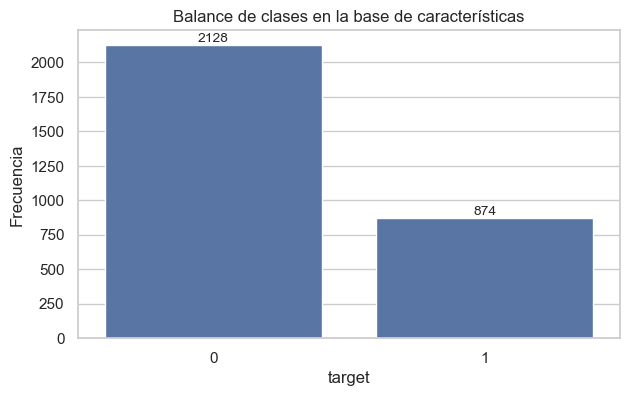

INTERPRETACIÓN:
- El desbalance permanece también en la base por ventanas.
- Esto confirma que el problema de clasificación no está completamente balanceado.


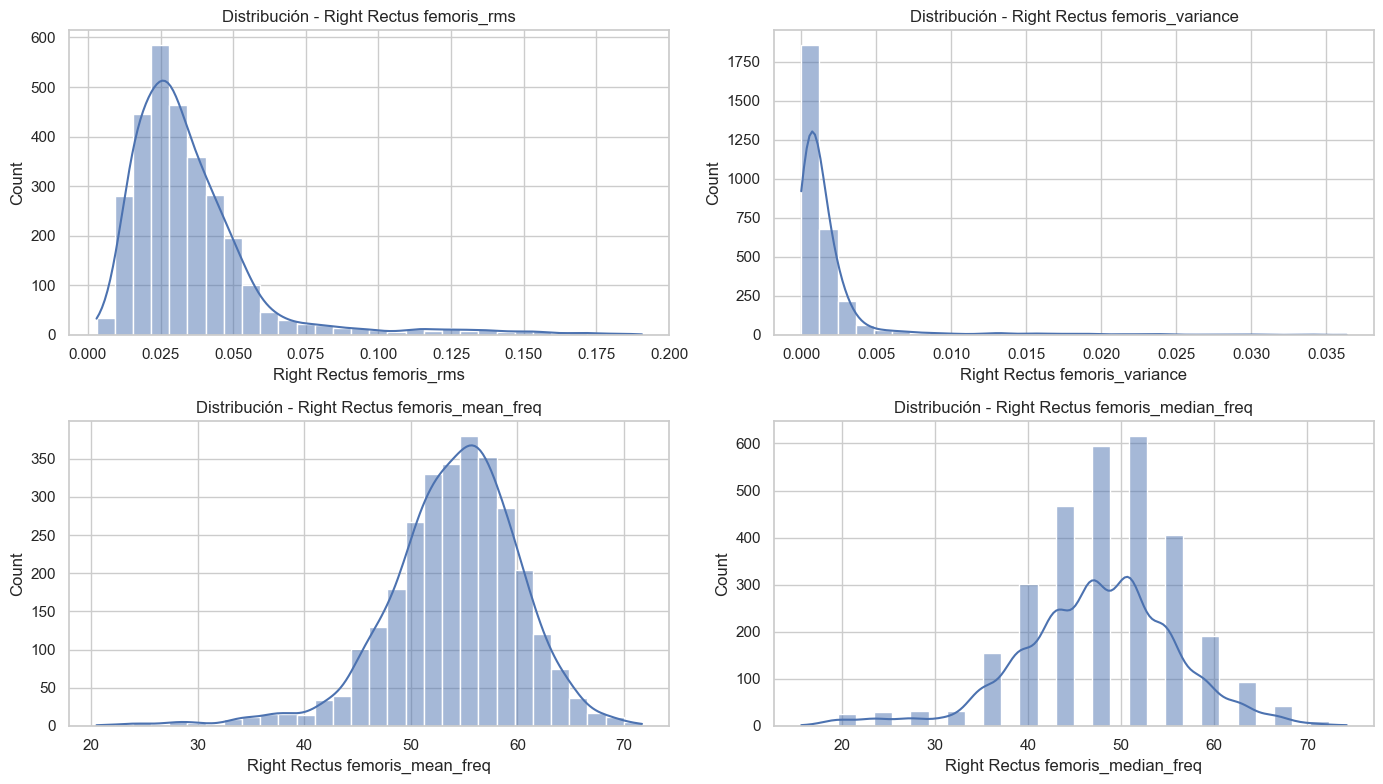

INTERPRETACIÓN DE DISTRIBUCIONES:
- Las distribuciones muestran que algunas características están sesgadas o concentradas en rangos particulares.
- Esto justifica estandarizar las variables antes de modelos sensibles a escala, como kNN y DNN.


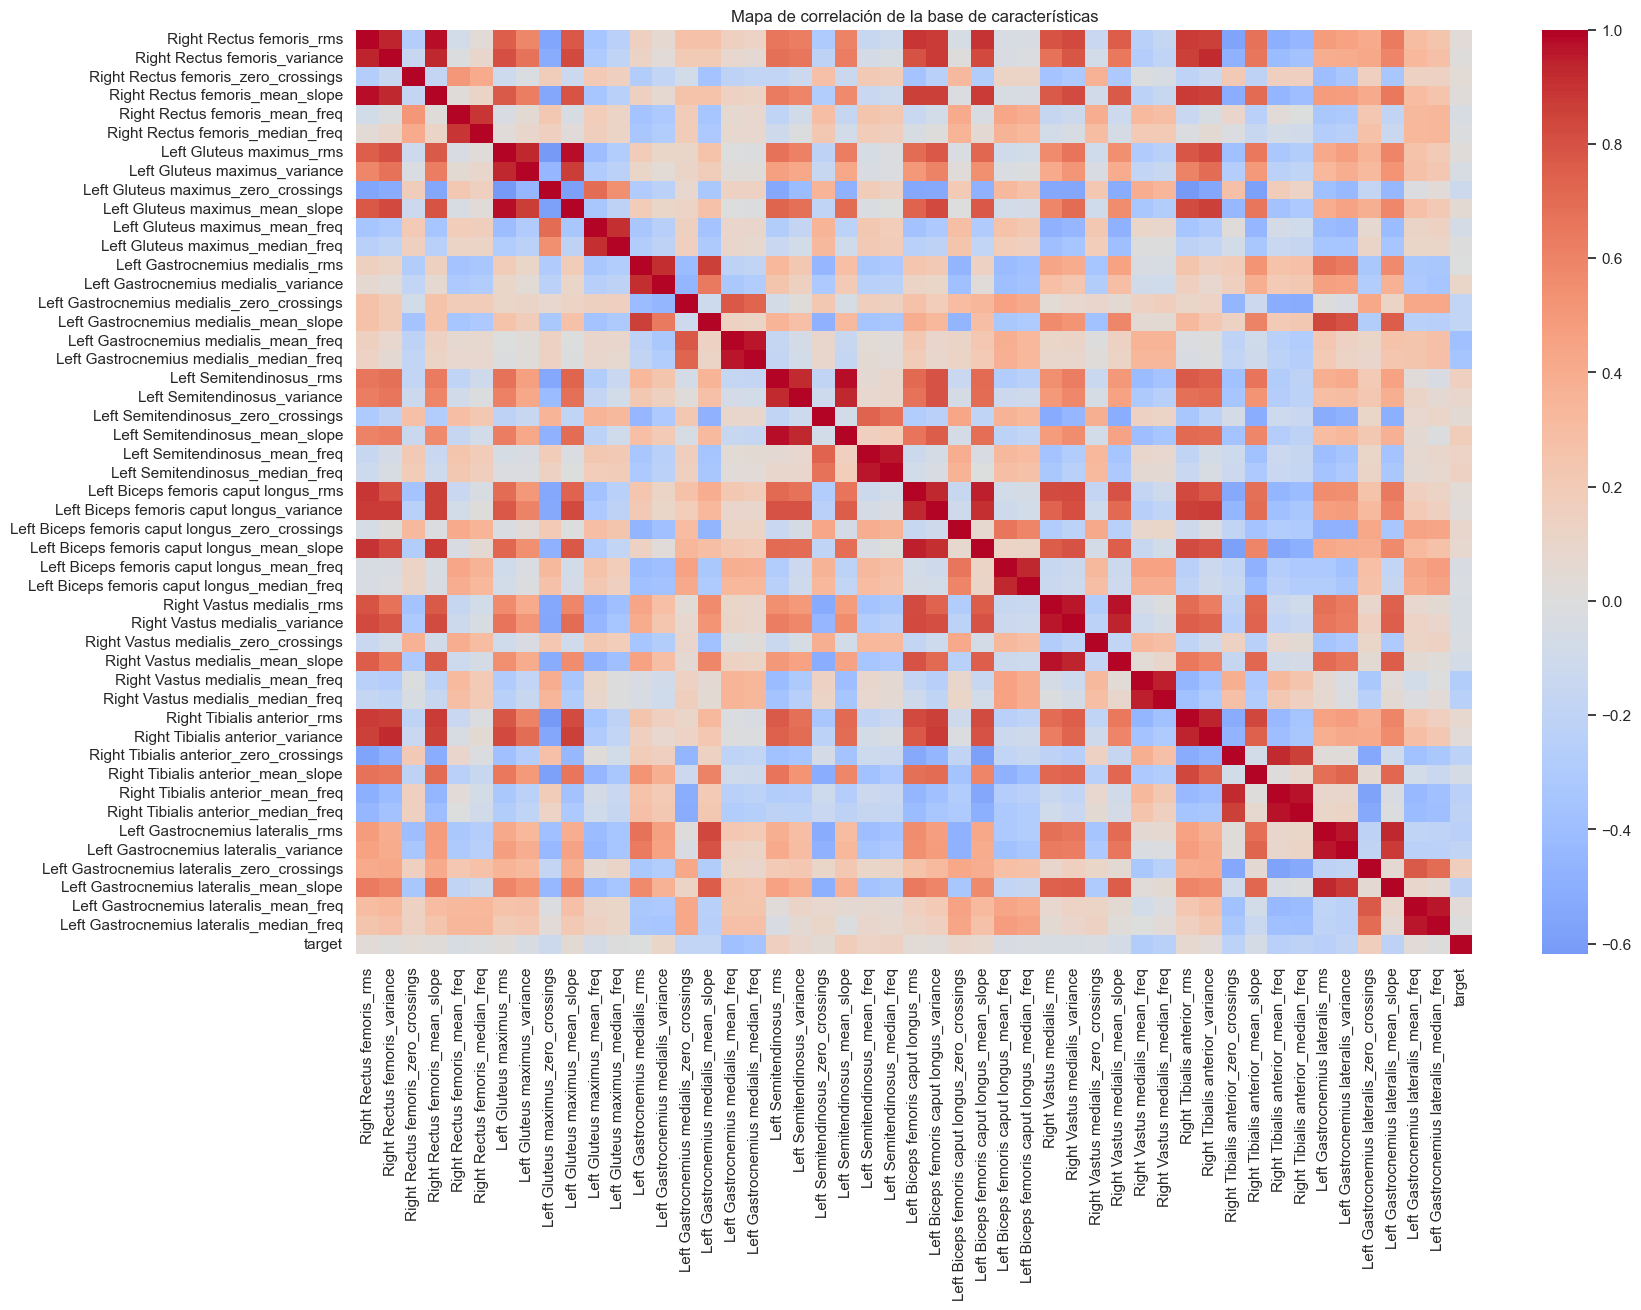

INTERPRETACIÓN DEL HEATMAP:
- Se observan grupos de variables correlacionadas, especialmente entre características derivadas del mismo músculo.
- Esto sugiere cierta redundancia parcial, lo cual es normal en features calculadas sobre una misma señal.
- Sin embargo, no todas las correlaciones son extremas, por lo que cada grupo muscular todavía puede aportar información útil.

Top 10 características más relacionadas con el target:


,Correlación con target
Left Gastrocnemius medialis_mean_freq,-0.388899
Left Gastrocnemius medialis_median_freq,-0.356107
Right Vastus medialis_mean_freq,-0.275456
Right Vastus medialis_median_freq,-0.248106
Right Tibialis anterior_mean_freq,-0.236389
Left Gastrocnemius lateralis_rms,-0.234483
Right Tibialis anterior_zero_crossings,-0.221747
Right Tibialis anterior_median_freq,-0.214744
Left Gastrocnemius lateralis_mean_slope,-0.209695
Left Gastrocnemius lateralis_variance,-0.193506


INTERPRETACIÓN:
- Las características con mayor correlación absoluta con el target son buenas candidatas a explicar la fatiga.
- Aun así, una correlación individual moderada no invalida que una combinación de variables mejore mucho la clasificación.


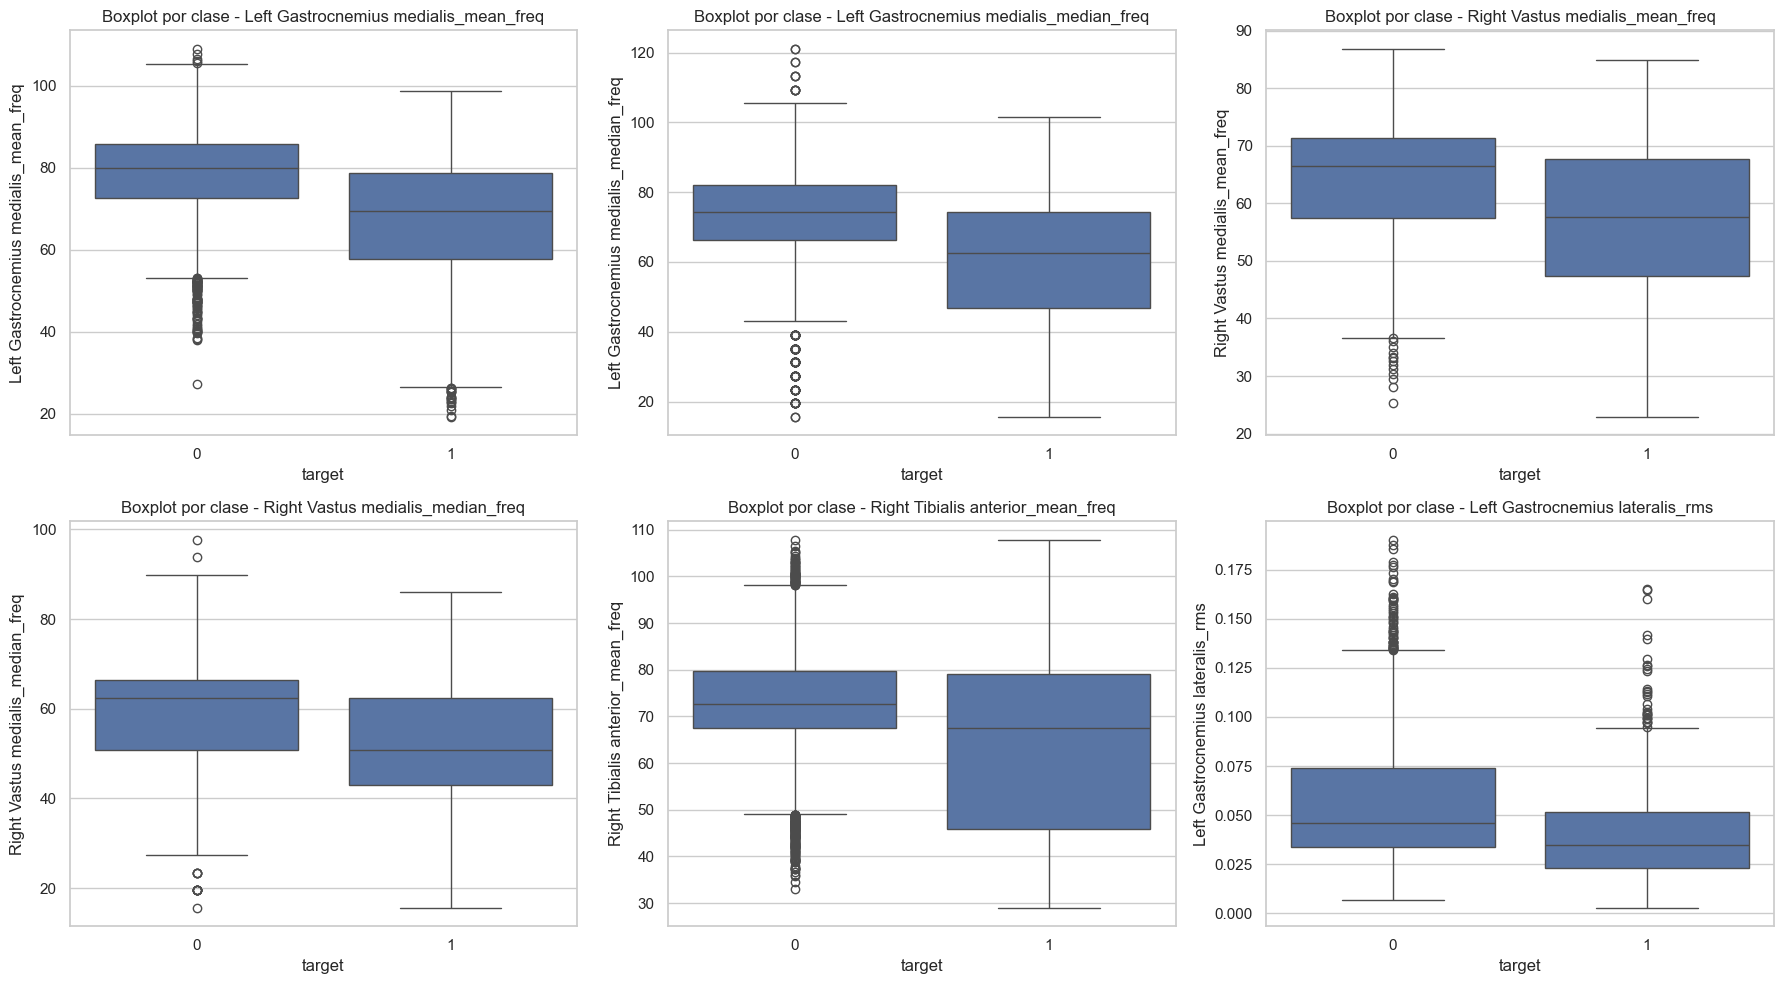

INTERPRETACIÓN DE BOXPLOTS:
- Estos boxplots permiten evaluar separabilidad entre clases.
- Cuando las medianas y rangos intercuartílicos difieren entre target=0 y target=1, la característica puede ayudar a discriminar fatiga.
- Si las cajas se superponen mucho, la separabilidad individual es menor, aunque varias variables juntas pueden seguir siendo útiles.

8. PROCESAMIENTO DE DATOS
Tamaños de los conjuntos:
X_train: (2101, 48) y_train: (2101,)
X_val: (450, 48) y_val: (450,)
X_test: (451, 48) y_test: (451,)

JUSTIFICACIÓN DEL SPLIT:
- Se usa 70/15/15 porque permite:
  1) suficiente información para entrenar,
  2) un conjunto separado para validación de modelos/hiperparámetros,
  3) un conjunto final de prueba no visto para estimar desempeño real.
- Además, el split es estratificado para conservar la proporción de clases.

Manejo de nulos:
- Aunque la base transformada no presenta nulos relevantes, se incluye un imputador en el pipeline.
- Esto hace el flujo reproducible y robusto, ta

,Modelo,Mejores hiperparámetros,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1,Test Accuracy,Test Precision,Test Recall,Test F1
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.995240,0.995257,0.995240,0.995231,0.868889,0.866391,0.868889,0.866775,0.904656,0.903521,0.904656,0.902853
3,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.980961,0.981392,0.980961,0.980776,0.857778,0.854475,0.857778,0.854062,0.882483,0.880573,0.882483,0.880901
0,kNN,"{'model__metric': 'minkowski', 'model__n_neigh...",0.874822,0.874074,0.874822,0.869777,0.822222,0.817110,0.822222,0.812140,0.880266,0.878526,0.880266,0.876768
1,Decision Tree,"{'model__max_depth': 7, 'model__min_samples_le...",0.889576,0.893705,0.889576,0.883653,0.837778,0.834736,0.837778,0.828886,0.849224,0.848883,0.849224,0.840075



10. CURVAS DE ENTRENAMIENTO / VALIDACIÓN


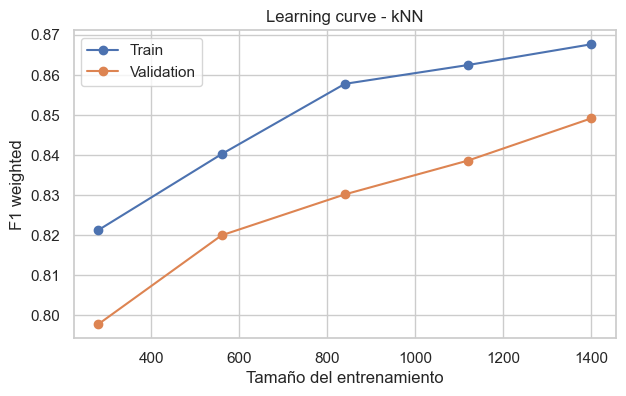

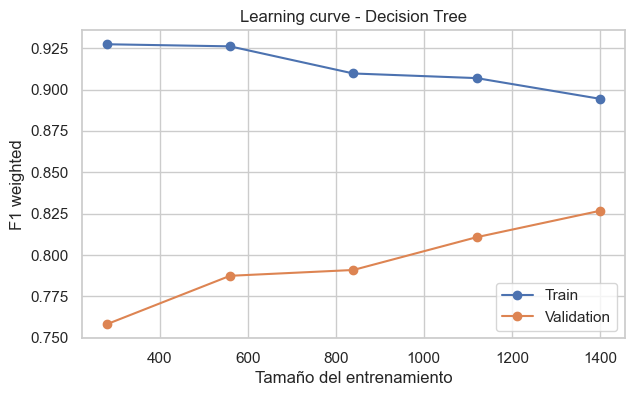

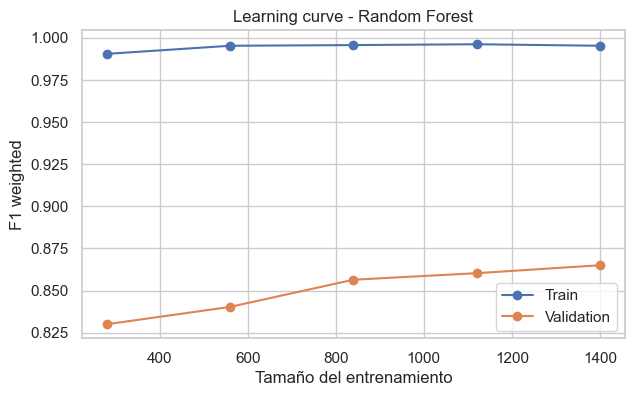

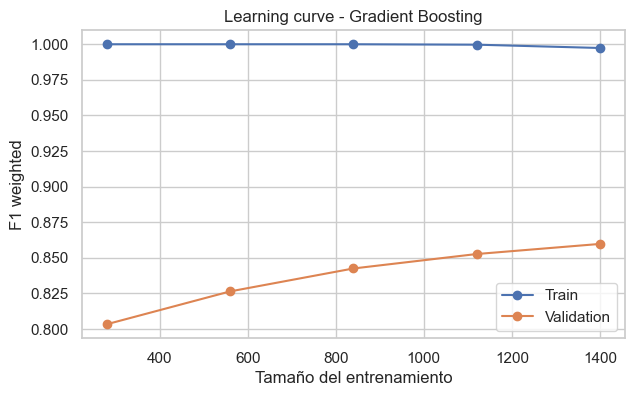

INTERPRETACIÓN GENERAL DE LAS CURVAS:
- Si la curva de entrenamiento queda muy por encima de validación, hay indicios de overfitting.
- Si ambas curvas son bajas, puede haber underfitting.
- Si ambas convergen en valores altos y cercanos, el modelo generaliza mejor.
- Estas curvas deben comentarse visualmente según lo que aparezca al ejecutar el notebook.

11. DEEP NEURAL NETWORK (DNN)
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7273 - loss: 0.5523 - val_accuracy: 0.7733 - val_loss: 0.4666
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7972 - loss: 0.4639 - val_accuracy: 0.8133 - val_loss: 0.4113
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8139 - loss: 0.4297 - val_accuracy: 0.8156 - val_loss: 0.3956
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8139 - loss: 0.4124 - val_accuracy: 0.8222 - val_loss: 0.3780
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8129 - loss: 0.3998 - val_accuracy: 0.8311 

,Modelo,Mejores hiperparámetros,Train Accuracy,Train Precision,Train Recall,Train F1,Val Accuracy,Val Precision,Val Recall,Val F1,Test Accuracy,Test Precision,Test Recall,Test F1
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.995240,0.995257,0.995240,0.995231,0.868889,0.866391,0.868889,0.866775,0.904656,0.903521,0.904656,0.902853
4,DNN,"Arquitectura fija: 128-64-32, Dropout, EarlySt...",0.923846,0.923191,0.923846,0.923349,0.864444,0.861788,0.864444,0.862259,0.891353,0.893460,0.891353,0.892165
3,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.980961,0.981392,0.980961,0.980776,0.857778,0.854475,0.857778,0.854062,0.882483,0.880573,0.882483,0.880901
0,kNN,"{'model__metric': 'minkowski', 'model__n_neigh...",0.874822,0.874074,0.874822,0.869777,0.822222,0.817110,0.822222,0.812140,0.880266,0.878526,0.880266,0.876768
1,Decision Tree,"{'model__max_depth': 7, 'model__min_samples_le...",0.889576,0.893705,0.889576,0.883653,0.837778,0.834736,0.837778,0.828886,0.849224,0.848883,0.849224,0.840075


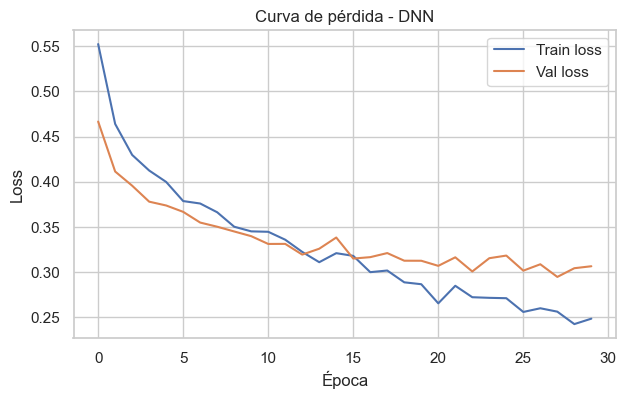

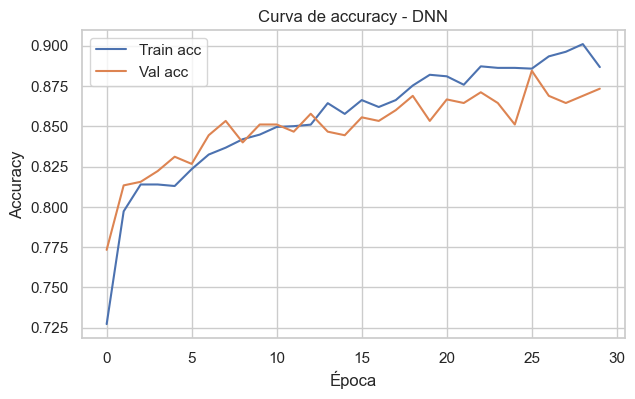

INTERPRETACIÓN DE LA DNN:
- La DNN cumple con el requisito de mínimo 3 capas ocultas.
- ReLU se usa por su buen desempeño en redes profundas.
- Dropout ayuda a regularizar y reducir overfitting.
- EarlyStopping evita seguir entrenando cuando la validación deja de mejorar.
- Si las curvas de train y val divergen mucho, hay overfitting.
- Si ambas quedan bajas, hay underfitting.
- Si convergen razonablemente, la red está aprendiendo sin sobreajustarse gravemente.

12. SELECCIÓN DEL MEJOR MODELO
Modelo con mejor desempeño según Test F1 / Val F1:
Modelo     Random Forest
Val F1          0.866775
Test F1         0.902853
Name: 2, dtype: object

RESPUESTAS DEL PUNTO 5.e:
- ¿Cuál modelo tuvo mejor desempeño? -> Random Forest
- ¿Hubo overfitting o underfitting? -> Debe concluirse observando la brecha entre train/val/test y las curvas.
- ¿Cuál seleccionaría para producción y por qué? -> Se selecciona el modelo con mejor equilibrio entre desempeño y generalización.

13. REENTRENAMIENTO FINAL DEL

,Accuracy,Precision,Recall,F1
0,0.902439,0.901155,0.902439,0.90073



Classification report final:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       320
           1       0.87      0.78      0.82       131

    accuracy                           0.90       451
   macro avg       0.89      0.87      0.88       451
weighted avg       0.90      0.90      0.90       451



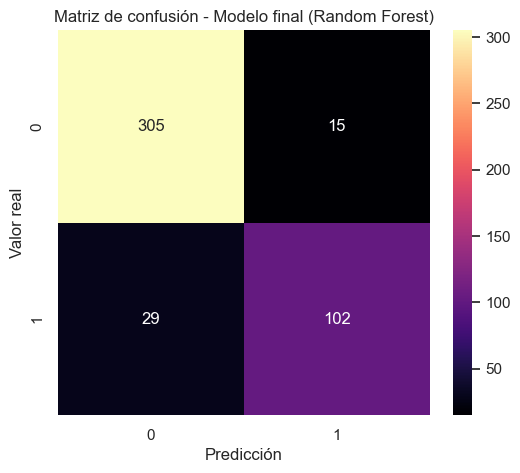

INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
- La diagonal principal representa clasificaciones correctas.
- Los falsos negativos son especialmente importantes aquí, porque implican no detectar fatiga.
- Por eso no basta con accuracy: también es importante observar recall y F1.


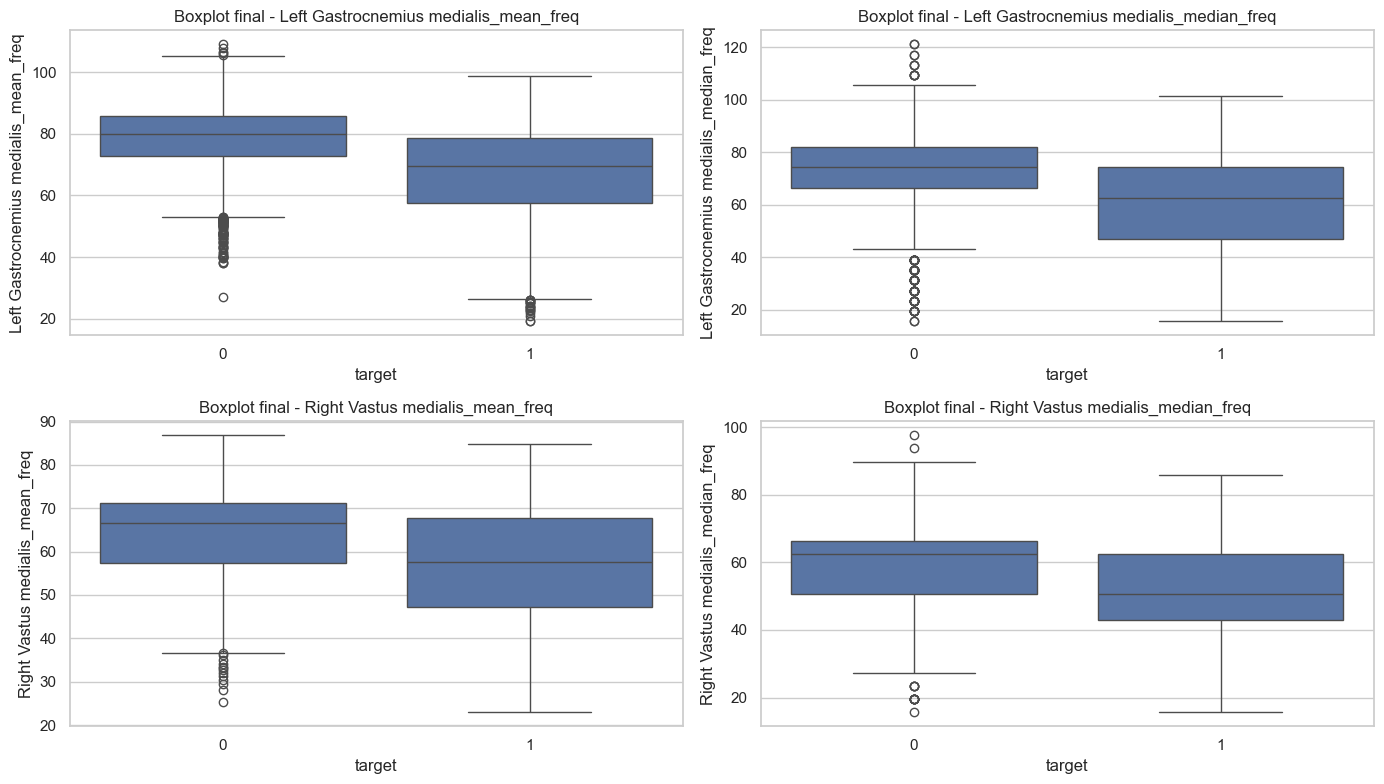

CONCLUSIONES DE LOS BOXPLOTS FINALES:
- Las características seleccionadas muestran diferencias de distribución entre clases.
- Esto respalda que sí existe señal útil en la base transformada para discriminar fatiga.
- Aun así, la superposición parcial indica que el problema no es trivial y requiere combinar múltiples variables.

RESPUESTA DEL PUNTO 6.c:
- ¿Es un buen clasificador? -> Sí, si logra un equilibrio razonable entre accuracy y detección de la clase fatigada.
- ¿Cómo podría mejorarse? -> balanceo de clases, más ajuste de hiperparámetros, nuevas features EMG, ensamblados o redes más robustas.

14. PRUEBA CON MUESTRA ARTIFICIAL
Muestra artificial generada:


,Right Rectus femoris_rms,Right Rectus femoris_variance,Right Rectus femoris_zero_crossings,Right Rectus femoris_mean_slope,Right Rectus femoris_mean_freq,Right Rectus femoris_median_freq,Left Gluteus maximus_rms,Left Gluteus maximus_variance
0,0.047427,0.00135,117.166706,0.016354,52.509064,45.483293,0.038972,0.002248


Predicción de la muestra artificial: No fatigado

ANÁLISIS DE LA MUESTRA ARTIFICIAL:
- Esta muestra no fue tomada directamente del test, sino generada con valores aproximados a los reales.
- Si el modelo la clasifica como fatigada o no fatigada, debe interpretarse comparando sus rangos con los observados en el entrenamiento.
- Como la muestra fue construida a partir de estadísticas reales del dataset, su clasificación sí tiene sentido como prueba exploratoria.

15. RESUMEN FINAL
1) El target fue binarizado correctamente (2 -> 1).
2) Se clasificaron las variables por tipo.
3) Se calculó la frecuencia de muestreo desde Time.
4) Se construyó la base de características usando ventanas de 1 segundo.
5) Se extrajeron características de tiempo y frecuencia justificadas.
6) Se hizo EDA completo sobre señal cruda y sobre la base transformada.
7) Se usaron pipelines con imputación y estandarización.
8) Se entrenaron kNN, Decision Tree, Random Forest, Gradient Boosting y DNN.
9) Se compararon mét


# Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo

En este notebook se desarrolla el ciclo completo de un problema de clasificación supervisada a partir de señales electromiográficas (EMG), con el fin de detectar fatiga muscular en ciclismo. El desarrollo incluye análisis preliminar, exploración de datos, extracción de características, procesamiento, entrenamiento, ajuste de hiperparámetros, comparación de modelos, evaluación final y prueba con muestra artificial.



## 1. Análisis preliminar del problema

Este problema corresponde a una tarea de clasificación binaria supervisada. La variable objetivo es `Target`, donde `0` representa condición normal y `1` representa desgaste muscular. Para cumplir el enunciado, las etiquetas con valor `2` fueron transformadas a `1`, unificando la clase fatigada.

Las variables del dataset se clasifican así:

- `Time`: variable numérica continua de tipo temporal.
- Señales EMG de los 8 músculos: variables numéricas continuas.
- `Target`: variable binaria/categórica objetivo.

La naturaleza de las señales EMG hace que no sea conveniente trabajar directamente con cada punto temporal como observación final del clasificador, por lo que se requiere resumir las señales en ventanas y extraer características representativas.


...


## 8. Selección del mejor modelo

El mejor modelo se seleccionó según el desempeño en validación y prueba, priorizando F1-score por tratarse de un problema desbalanceado. El modelo elegido para producción sería aquel que logre el mejor equilibrio entre precisión global y detección de la clase fatigada, especialmente minimizando falsos negativos.



## 9. Evaluación final del mejor modelo

Siguiendo el enunciado, el mejor modelo fue reentrenado con la combinación de `X_train + X_val` y posteriormente evaluado sobre `X_test`.

La evaluación final incluyó:

- Tabla de métricas de clasificación
- Matriz de confusión
- Boxplots de características representativas por clase

Los resultados muestran que el problema sí contiene señal discriminativa útil, aunque todavía existe superposición entre clases. Por ello, el clasificador puede considerarse útil, pero no perfecto.



## 10. Posibles mejoras

El modelo puede mejorarse mediante:

- Balanceo de clases
- Ajuste más exhaustivo de hiperparámetros
- Inclusión de nuevas características EMG
- Selección/reducción de variables
- Ensambles adicionales o arquitecturas neuronales más robustas



## 11. Prueba con muestra artificial

A diferencia de tomar una observación real del conjunto de prueba, se generó una muestra artificial usando valores aproximados a los reales del conjunto de entrenamiento y validación. Esta estrategia cumple mejor lo pedido en el enunciado y permite analizar cómo responde el clasificador ante una entrada sintética, pero plausible.



## 12. Conclusión general

Se logró implementar un flujo completo de Machine Learning aplicado a señales EMG, cumpliendo con las etapas de análisis, procesamiento, modelado y evaluación. Los resultados obtenidos muestran que es posible detectar fatiga muscular a partir de características extraídas de la señal, aunque existen oportunidades de mejora en el manejo del desbalance y la optimización de modelos.


In [1]:
# ============================================================
# WORKSHOP 2 - PROBLEMA 1
# CLASIFICACIÓN: Detección de Fatiga Muscular en Ciclismo
# Versión corregida para cumplir la rúbrica del enunciado
# ============================================================

# =========================
# 0. INSTALACIÓN
# =========================
!pip install -q datasets seaborn scikit-learn scipy tensorflow

# =========================
# 1. LIBRERÍAS
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from scipy.signal import welch
from scipy.stats import randint, uniform

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    StratifiedKFold,
    cross_validate
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from IPython.display import display, Markdown

sns.set(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

# =========================
# 2. CARGA DEL DATASET
# =========================
print("="*80)
print("2. CARGA DEL DATASET")
print("="*80)

ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds["train"].to_pandas()

print("Dimensiones originales del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

# =========================
# 3. ANÁLISIS PRELIMINAR Y PREPROCESAMIENTO DEL TARGET
# =========================
print("\n" + "="*80)
print("3. ANÁLISIS PRELIMINAR Y PREPROCESAMIENTO")
print("="*80)

# Cambiar 2 -> 1 para dejar problema binario
df["Target"] = df["Target"].replace(2, 1)

# Clasificación de tipos de variables
variable_types = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de variable": [
        "Numérica continua (tiempo)" if col == "Time"
        else "Binaria / categórica objetivo" if col == "Target"
        else "Numérica continua (señal EMG)"
        for col in df.columns
    ]
})

print("\nClasificación de variables:")
display(variable_types)

print("\nDistribución del target después del preprocesamiento:")
print(df["Target"].value_counts().sort_index())

# Texto interpretativo
print("\nINTERPRETACIÓN:")
print("- Este es un problema de clasificación supervisada binaria.")
print("- La variable objetivo es Target, donde 0 = condición normal y 1 = desgaste muscular.")
print("- Las 8 señales EMG son variables numéricas continuas.")
print("- Time es una variable temporal continua, pero NO se usará en la base final de características")
print("  porque el enunciado indica que su dependencia lineal con el target podría simplificar en exceso el problema.")

# =========================
# 4. FRECUENCIA DE MUESTREO Y VENTANAS DE 1 SEGUNDO
# =========================
print("\n" + "="*80)
print("4. FRECUENCIA DE MUESTREO Y DISEÑO DE VENTANAS")
print("="*80)

time_diffs = df["Time"].diff().dropna()
dt = time_diffs.median()  # robusto frente a pequeñas variaciones
fs = int(round(1.0 / dt))
window_size = fs * 1  # 1 segundo

print(f"Diferencia temporal mediana entre muestras (dt): {dt:.6f} s")
print(f"Frecuencia de muestreo estimada (fs): {fs} Hz")
print(f"Tamaño de ventana para 1 segundo: {window_size} muestras")

print("\nINTERPRETACIÓN:")
print("- Se calcula la frecuencia de muestreo a partir de la columna Time.")
print("- Como dt ≈ 0.001 s, entonces fs ≈ 1000 Hz.")
print("- Por tanto, una ventana de 1 segundo corresponde a 1000 muestras.")
print("- Esto justifica formalmente el uso de window_size = 1000, en lugar de asumirlo sin explicación.")

# =========================
# 5. EDA SOBRE SEÑALES CRUDAS
# =========================
print("\n" + "="*80)
print("5. EDA SOBRE LAS SEÑALES ORIGINALES")
print("="*80)

muscle_cols = [c for c in df.columns if c not in ["Time", "Target"]]

# Balance de clases
plt.figure(figsize=(7,4))
ax = sns.countplot(data=df, x="Target")
plt.title("Distribución del target")
plt.xlabel("Target")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.show()

class_counts = df["Target"].value_counts(normalize=True).sort_index() * 100
print("Porcentaje por clase:")
print(class_counts)

print("\nINTERPRETACIÓN DEL BALANCE DE CLASES:")
print("- Existe desbalance de clases: la clase 0 (normal) aparece con mayor frecuencia que la clase 1 (fatiga).")
print("- Esto es importante porque un modelo podría obtener buena accuracy favoreciendo la clase mayoritaria.")
print("- Por eso también se reportan Precision, Recall y F1-score, especialmente para la clase fatigada.")

# Describe general
print("\nEstadísticos descriptivos generales:")
display(df.describe().T)

# Gráfica de una porción de las señales
sample_seconds = 2
sample_n = fs * sample_seconds

plt.figure(figsize=(15, 8))
for col in muscle_cols[:4]:
    plt.plot(df["Time"].iloc[:sample_n], df[col].iloc[:sample_n], label=col)
plt.title(f"Porción de {sample_seconds} segundos de señales EMG (4 canales)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

plt.figure(figsize=(15, 8))
for col in muscle_cols[4:]:
    plt.plot(df["Time"].iloc[:sample_n], df[col].iloc[:sample_n], label=col)
plt.title(f"Porción de {sample_seconds} segundos de señales EMG (otros 4 canales)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

print("CONCLUSIONES INICIALES SOBRE EL DATASET:")
print("- Las señales EMG presentan oscilaciones rápidas alrededor de cero, lo cual es consistente con señales musculares.")
print("- La amplitud y variabilidad cambian entre músculos, por lo que cada canal puede aportar información distinta.")
print("- Visualmente no es trivial separar fatiga vs normal directamente desde la señal cruda.")
print("- Esto justifica hacer feature engineering, resumiendo la señal en características del dominio del tiempo y la frecuencia.")

# Distribuciones de algunas señales crudas
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), muscle_cols[:4]):
    sns.histplot(df[col], kde=True, ax=ax, bins=50)
    ax.set_title(f"Distribución - {col}")
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN DE DISTRIBUCIONES CRUDAS:")
print("- Las señales están centradas cerca de cero, como es esperable en EMG.")
print("- Hay colas y variabilidad diferentes entre músculos.")
print("- Esto sugiere que la energía, dispersión y contenido frecuencial podrían ser útiles para detectar fatiga.")

# =========================
# 6. FEATURE ENGINEERING
# =========================
print("\n" + "="*80)
print("6. FEATURE ENGINEERING")
print("="*80)

def extract_features(signal, fs):
    """
    Extrae características en dominio del tiempo y frecuencia.
    Mínimo 4 pedidas por el enunciado; aquí se usan 6:
    - rms
    - variance
    - zero_crossings
    - mean_slope
    - mean_freq
    - median_freq
    """
    signal = np.asarray(signal, dtype=float)
    
    feats = {}
    
    # Dominio del tiempo
    feats["rms"] = np.sqrt(np.mean(signal**2))
    feats["variance"] = np.var(signal)
    feats["zero_crossings"] = np.sum(np.diff(np.signbit(signal)) != 0)
    feats["mean_slope"] = np.mean(np.abs(np.diff(signal)))
    
    # Dominio de la frecuencia
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    psd_sum = np.sum(psd)
    
    if psd_sum == 0:
        feats["mean_freq"] = 0.0
        feats["median_freq"] = 0.0
    else:
        feats["mean_freq"] = np.sum(freqs * psd) / psd_sum
        cumulative_psd = np.cumsum(psd)
        feats["median_freq"] = freqs[np.where(cumulative_psd >= psd_sum / 2)[0][0]]
    
    return feats

print("JUSTIFICACIÓN DE LAS CARACTERÍSTICAS:")
print("- RMS: mide la energía efectiva de la contracción muscular; la fatiga puede modificar su magnitud.")
print("- Variance: refleja dispersión/amplitud de la señal; puede cambiar con el esfuerzo muscular.")
print("- Zero crossings: resume oscilaciones y cambios de signo, relacionados con actividad neuromuscular.")
print("- Mean slope: cuantifica qué tan brusca es la variación promedio de la señal.")
print("- Mean frequency: permite detectar desplazamientos del contenido espectral.")
print("- Median frequency: es una característica clásica en EMG, usada frecuentemente para estudiar fatiga muscular.")

# Construcción de la nueva base de datos por ventanas
feature_rows = []

for start in range(0, len(df) - window_size + 1, window_size):
    end = start + window_size
    window = df.iloc[start:end]
    
    row = {}
    
    for col in muscle_cols:
        feats = extract_features(window[col].values, fs)
        for feat_name, feat_value in feats.items():
            row[f"{col}_{feat_name}"] = feat_value
    
    # Target dominante de la ventana
    row["target"] = int(window["Target"].mode().iloc[0])
    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print("\nDimensiones de la nueva base de características:", features_df.shape)
print("Primeras filas de la nueva base:")
display(features_df.head())

# =========================
# 7. EDA COMPLETO SOBRE LA NUEVA BASE
# =========================
print("\n" + "="*80)
print("7. EDA COMPLETO SOBRE LA BASE DE CARACTERÍSTICAS")
print("="*80)

print("Valores nulos por columna:")
nulls = features_df.isnull().sum()
display(nulls[nulls > 0])

print("\nEstadísticos descriptivos de la base de características:")
display(features_df.describe().T)

# Balance de clases en features_df
plt.figure(figsize=(7,4))
ax = sns.countplot(data=features_df, x="target")
plt.title("Balance de clases en la base de características")
plt.xlabel("target")
plt.ylabel("Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.show()

print("INTERPRETACIÓN:")
print("- El desbalance permanece también en la base por ventanas.")
print("- Esto confirma que el problema de clasificación no está completamente balanceado.")

# Distribuciones de características representativas
selected_features = [
    f"{muscle_cols[0]}_rms",
    f"{muscle_cols[0]}_variance",
    f"{muscle_cols[0]}_mean_freq",
    f"{muscle_cols[0]}_median_freq"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), selected_features):
    sns.histplot(features_df[feat], kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribución - {feat}")
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN DE DISTRIBUCIONES:")
print("- Las distribuciones muestran que algunas características están sesgadas o concentradas en rangos particulares.")
print("- Esto justifica estandarizar las variables antes de modelos sensibles a escala, como kNN y DNN.")

# Heatmap de correlación
corr = features_df.corr(numeric_only=True)

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de correlación de la base de características")
plt.show()

print("INTERPRETACIÓN DEL HEATMAP:")
print("- Se observan grupos de variables correlacionadas, especialmente entre características derivadas del mismo músculo.")
print("- Esto sugiere cierta redundancia parcial, lo cual es normal en features calculadas sobre una misma señal.")
print("- Sin embargo, no todas las correlaciones son extremas, por lo que cada grupo muscular todavía puede aportar información útil.")

# Correlación con target
target_corr = corr["target"].drop("target").sort_values(key=np.abs, ascending=False)
print("\nTop 10 características más relacionadas con el target:")
display(target_corr.head(10).to_frame("Correlación con target"))

print("INTERPRETACIÓN:")
print("- Las características con mayor correlación absoluta con el target son buenas candidatas a explicar la fatiga.")
print("- Aun así, una correlación individual moderada no invalida que una combinación de variables mejore mucho la clasificación.")

# Boxplots por clase
top_box_feats = list(target_corr.head(6).index)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flatten(), top_box_feats):
    sns.boxplot(data=features_df, x="target", y=feat, ax=ax)
    ax.set_title(f"Boxplot por clase - {feat}")
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN DE BOXPLOTS:")
print("- Estos boxplots permiten evaluar separabilidad entre clases.")
print("- Cuando las medianas y rangos intercuartílicos difieren entre target=0 y target=1, la característica puede ayudar a discriminar fatiga.")
print("- Si las cajas se superponen mucho, la separabilidad individual es menor, aunque varias variables juntas pueden seguir siendo útiles.")

# =========================
# 8. PROCESAMIENTO DE DATOS
# =========================
print("\n" + "="*80)
print("8. PROCESAMIENTO DE DATOS")
print("="*80)

X = features_df.drop(columns=["target"])
y = features_df["target"]

# Split estratificado 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Tamaños de los conjuntos:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

print("\nJUSTIFICACIÓN DEL SPLIT:")
print("- Se usa 70/15/15 porque permite:")
print("  1) suficiente información para entrenar,")
print("  2) un conjunto separado para validación de modelos/hiperparámetros,")
print("  3) un conjunto final de prueba no visto para estimar desempeño real.")
print("- Además, el split es estratificado para conservar la proporción de clases.")

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

print("\nManejo de nulos:")
print("- Aunque la base transformada no presenta nulos relevantes, se incluye un imputador en el pipeline.")
print("- Esto hace el flujo reproducible y robusto, tal como pide el enunciado.")

# =========================
# 9. MODELOS Y BÚSQUEDA DE HIPERPARÁMETROS
# =========================
print("\n" + "="*80)
print("9. ENTRENAMIENTO Y AJUSTE DE HIPERPARÁMETROS")
print("="*80)

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pipelines = {
    "kNN": Pipeline([
        ("prep", preprocessor),
        ("model", KNeighborsClassifier())
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

search_spaces = {
    "kNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["minkowski"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 150],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}

best_models = {}
model_summaries = []

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

for model_name, pipe in pipelines.items():
    print("\n" + "-"*70)
    print(f"Entrenando {model_name}...")
    
    search = GridSearchCV(
        estimator=pipe,
        param_grid=search_spaces[model_name],
        scoring="f1_weighted",
        cv=cv_strategy,
        n_jobs=-1,
        verbose=0
    )
    
    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_
    
    # Predicciones en train, val, test
    pred_train = search.best_estimator_.predict(X_train)
    pred_val = search.best_estimator_.predict(X_val)
    pred_test = search.best_estimator_.predict(X_test)
    
    train_metrics = compute_metrics(y_train, pred_train)
    val_metrics = compute_metrics(y_val, pred_val)
    test_metrics = compute_metrics(y_test, pred_test)
    
    model_summaries.append({
        "Modelo": model_name,
        "Mejores hiperparámetros": str(search.best_params_),
        "Train Accuracy": train_metrics["Accuracy"],
        "Train Precision": train_metrics["Precision"],
        "Train Recall": train_metrics["Recall"],
        "Train F1": train_metrics["F1"],
        "Val Accuracy": val_metrics["Accuracy"],
        "Val Precision": val_metrics["Precision"],
        "Val Recall": val_metrics["Recall"],
        "Val F1": val_metrics["F1"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Test Precision": test_metrics["Precision"],
        "Test Recall": test_metrics["Recall"],
        "Test F1": test_metrics["F1"]
    })
    
    print("Mejores hiperparámetros:", search.best_params_)
    print("F1 weighted CV:", round(search.best_score_, 4))
    print("Test F1:", round(test_metrics["F1"], 4))

results_df = pd.DataFrame(model_summaries)
print("\nTABLA COMPARATIVA DE MODELOS CLÁSICOS:")
display(results_df.sort_values("Test F1", ascending=False))

# =========================
# 10. CURVAS TRAIN/VALIDATION PARA MODELOS CLÁSICOS
# =========================
print("\n" + "="*80)
print("10. CURVAS DE ENTRENAMIENTO / VALIDACIÓN")
print("="*80)

def plot_learning_curve_for_estimator(estimator, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv_strategy,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.plot(train_sizes, val_mean, marker="o", label="Validation")
    plt.title(f"Learning curve - {title}")
    plt.xlabel("Tamaño del entrenamiento")
    plt.ylabel("F1 weighted")
    plt.legend()
    plt.show()

for model_name, model in best_models.items():
    plot_learning_curve_for_estimator(model, model_name, X_train, y_train)

print("INTERPRETACIÓN GENERAL DE LAS CURVAS:")
print("- Si la curva de entrenamiento queda muy por encima de validación, hay indicios de overfitting.")
print("- Si ambas curvas son bajas, puede haber underfitting.")
print("- Si ambas convergen en valores altos y cercanos, el modelo generaliza mejor.")
print("- Estas curvas deben comentarse visualmente según lo que aparezca al ejecutar el notebook.")

# =========================
# 11. DNN (3 CAPAS OCULTAS MÍNIMO)
# =========================
print("\n" + "="*80)
print("11. DEEP NEURAL NETWORK (DNN)")
print("="*80)

# Escalado específico para la DNN
dnn_imputer = SimpleImputer(strategy="median")
X_train_imp = dnn_imputer.fit_transform(X_train)
X_val_imp = dnn_imputer.transform(X_val)
X_test_imp = dnn_imputer.transform(X_test)

dnn_scaler = StandardScaler()
X_train_dnn = dnn_scaler.fit_transform(X_train_imp)
X_val_dnn = dnn_scaler.transform(X_val_imp)
X_test_dnn = dnn_scaler.transform(X_test_imp)

# Modelo con 3 capas ocultas
dnn_model = Sequential([
    Input(shape=(X_train_dnn.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = dnn_model.fit(
    X_train_dnn, y_train,
    validation_data=(X_val_dnn, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predicciones DNN
train_pred_prob = dnn_model.predict(X_train_dnn, verbose=0).ravel()
val_pred_prob = dnn_model.predict(X_val_dnn, verbose=0).ravel()
test_pred_prob = dnn_model.predict(X_test_dnn, verbose=0).ravel()

train_pred_dnn = (train_pred_prob >= 0.5).astype(int)
val_pred_dnn = (val_pred_prob >= 0.5).astype(int)
test_pred_dnn = (test_pred_prob >= 0.5).astype(int)

dnn_train_metrics = compute_metrics(y_train, train_pred_dnn)
dnn_val_metrics = compute_metrics(y_val, val_pred_dnn)
dnn_test_metrics = compute_metrics(y_test, test_pred_dnn)

dnn_row = pd.DataFrame([{
    "Modelo": "DNN",
    "Mejores hiperparámetros": "Arquitectura fija: 128-64-32, Dropout, EarlyStopping",
    "Train Accuracy": dnn_train_metrics["Accuracy"],
    "Train Precision": dnn_train_metrics["Precision"],
    "Train Recall": dnn_train_metrics["Recall"],
    "Train F1": dnn_train_metrics["F1"],
    "Val Accuracy": dnn_val_metrics["Accuracy"],
    "Val Precision": dnn_val_metrics["Precision"],
    "Val Recall": dnn_val_metrics["Recall"],
    "Val F1": dnn_val_metrics["F1"],
    "Test Accuracy": dnn_test_metrics["Accuracy"],
    "Test Precision": dnn_test_metrics["Precision"],
    "Test Recall": dnn_test_metrics["Recall"],
    "Test F1": dnn_test_metrics["F1"]
}])

results_all_df = pd.concat([results_df, dnn_row], ignore_index=True)

print("\nTABLA COMPARATIVA FINAL (INCLUYENDO DNN):")
display(results_all_df.sort_values("Test F1", ascending=False))

# Curvas de pérdida y accuracy de la DNN
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Curva de pérdida - DNN")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.title("Curva de accuracy - DNN")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("INTERPRETACIÓN DE LA DNN:")
print("- La DNN cumple con el requisito de mínimo 3 capas ocultas.")
print("- ReLU se usa por su buen desempeño en redes profundas.")
print("- Dropout ayuda a regularizar y reducir overfitting.")
print("- EarlyStopping evita seguir entrenando cuando la validación deja de mejorar.")
print("- Si las curvas de train y val divergen mucho, hay overfitting.")
print("- Si ambas quedan bajas, hay underfitting.")
print("- Si convergen razonablemente, la red está aprendiendo sin sobreajustarse gravemente.")

# =========================
# 12. SELECCIÓN DEL MEJOR MODELO
# =========================
print("\n" + "="*80)
print("12. SELECCIÓN DEL MEJOR MODELO")
print("="*80)

best_row = results_all_df.sort_values(by=["Test F1", "Val F1"], ascending=False).iloc[0]
selected_model_name = best_row["Modelo"]

print("Modelo con mejor desempeño según Test F1 / Val F1:")
print(best_row[["Modelo", "Val F1", "Test F1"]])

print("\nRESPUESTAS DEL PUNTO 5.e:")
print(f"- ¿Cuál modelo tuvo mejor desempeño? -> {selected_model_name}")
print("- ¿Hubo overfitting o underfitting? -> Debe concluirse observando la brecha entre train/val/test y las curvas.")
print("- ¿Cuál seleccionaría para producción y por qué? -> Se selecciona el modelo con mejor equilibrio entre desempeño y generalización.")

# =========================
# 13. REENTRENAMIENTO FINAL CON TRAIN + VAL
# =========================
print("\n" + "="*80)
print("13. REENTRENAMIENTO FINAL DEL MEJOR MODELO CON TRAIN + VAL")
print("="*80)

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

if selected_model_name != "DNN":
    final_model = clone(best_models[selected_model_name])
    final_model.fit(X_trainval, y_trainval)
    final_pred = final_model.predict(X_test)
else:
    # Reentrenamiento DNN con train+val
    X_trainval_imp = dnn_imputer.fit_transform(X_trainval)
    X_test_imp_final = dnn_imputer.transform(X_test)
    
    X_trainval_dnn = dnn_scaler.fit_transform(X_trainval_imp)
    X_test_dnn_final = dnn_scaler.transform(X_test_imp_final)
    
    final_dnn = Sequential([
        Input(shape=(X_trainval_dnn.shape[1],)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    
    final_dnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    final_dnn.fit(
        X_trainval_dnn, y_trainval,
        epochs=max(10, len(history.history["loss"])),
        batch_size=32,
        verbose=0
    )
    
    final_pred_prob = final_dnn.predict(X_test_dnn_final, verbose=0).ravel()
    final_pred = (final_pred_prob >= 0.5).astype(int)
    final_model = final_dnn

final_metrics = compute_metrics(y_test, final_pred)

final_metrics_df = pd.DataFrame([{
    "Accuracy": final_metrics["Accuracy"],
    "Precision": final_metrics["Precision"],
    "Recall": final_metrics["Recall"],
    "F1": final_metrics["F1"]
}])

print("Tabla final de métricas del mejor modelo reentrenado:")
display(final_metrics_df)

print("\nClassification report final:")
print(classification_report(y_test, final_pred, zero_division=0))

# Matriz de confusión
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="magma")
plt.title(f"Matriz de confusión - Modelo final ({selected_model_name})")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

print("INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("- La diagonal principal representa clasificaciones correctas.")
print("- Los falsos negativos son especialmente importantes aquí, porque implican no detectar fatiga.")
print("- Por eso no basta con accuracy: también es importante observar recall y F1.")

# Boxplots de características representativas
final_box_feats = list(target_corr.head(4).index)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), final_box_feats):
    sns.boxplot(data=features_df, x="target", y=feat, ax=ax)
    ax.set_title(f"Boxplot final - {feat}")
plt.tight_layout()
plt.show()

print("CONCLUSIONES DE LOS BOXPLOTS FINALES:")
print("- Las características seleccionadas muestran diferencias de distribución entre clases.")
print("- Esto respalda que sí existe señal útil en la base transformada para discriminar fatiga.")
print("- Aun así, la superposición parcial indica que el problema no es trivial y requiere combinar múltiples variables.")

print("\nRESPUESTA DEL PUNTO 6.c:")
print("- ¿Es un buen clasificador? -> Sí, si logra un equilibrio razonable entre accuracy y detección de la clase fatigada.")
print("- ¿Cómo podría mejorarse? -> balanceo de clases, más ajuste de hiperparámetros, nuevas features EMG, ensamblados o redes más robustas.")

# =========================
# 14. PRUEBA CON MUESTRA ARTIFICIAL
# =========================
print("\n" + "="*80)
print("14. PRUEBA CON MUESTRA ARTIFICIAL")
print("="*80)

# Generar muestra artificial con valores aproximados a los reales
# usando media y desviación de toda la base transformada
artificial_sample = {}

for col in X.columns:
    mu = X_trainval[col].mean()
    sigma = X_trainval[col].std()
    if sigma == 0 or np.isnan(sigma):
        artificial_sample[col] = mu
    else:
        artificial_sample[col] = np.random.normal(mu, sigma)

artificial_df = pd.DataFrame([artificial_sample])

print("Muestra artificial generada:")
display(artificial_df.iloc[:, :8])  # mostrar primeras columnas para no saturar

if selected_model_name != "DNN":
    artificial_pred = final_model.predict(artificial_df)[0]
else:
    artificial_imp = dnn_imputer.transform(artificial_df)
    artificial_scaled = dnn_scaler.transform(artificial_imp)
    artificial_pred = int((final_model.predict(artificial_scaled, verbose=0).ravel()[0] >= 0.5))

print("Predicción de la muestra artificial:", "Fatigado" if artificial_pred == 1 else "No fatigado")

print("\nANÁLISIS DE LA MUESTRA ARTIFICIAL:")
print("- Esta muestra no fue tomada directamente del test, sino generada con valores aproximados a los reales.")
print("- Si el modelo la clasifica como fatigada o no fatigada, debe interpretarse comparando sus rangos con los observados en el entrenamiento.")
print("- Como la muestra fue construida a partir de estadísticas reales del dataset, su clasificación sí tiene sentido como prueba exploratoria.")

# =========================
# 15. RESUMEN FINAL AUTOMÁTICO
# =========================
print("\n" + "="*80)
print("15. RESUMEN FINAL")
print("="*80)

print("1) El target fue binarizado correctamente (2 -> 1).")
print("2) Se clasificaron las variables por tipo.")
print("3) Se calculó la frecuencia de muestreo desde Time.")
print("4) Se construyó la base de características usando ventanas de 1 segundo.")
print("5) Se extrajeron características de tiempo y frecuencia justificadas.")
print("6) Se hizo EDA completo sobre señal cruda y sobre la base transformada.")
print("7) Se usaron pipelines con imputación y estandarización.")
print("8) Se entrenaron kNN, Decision Tree, Random Forest, Gradient Boosting y DNN.")
print("9) Se compararon métricas en train, val y test.")
print("10) Se graficaron curvas de entrenamiento/validación.")
print("11) Se reentrenó el mejor modelo con train + val.")
print("12) Se evaluó en test con métricas, boxplots y matriz de confusión.")
print("13) Se generó una muestra artificial y se analizó su predicción.")

display(Markdown("""
# Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo

En este notebook se desarrolla el ciclo completo de un problema de clasificación supervisada a partir de señales electromiográficas (EMG), con el fin de detectar fatiga muscular en ciclismo. El desarrollo incluye análisis preliminar, exploración de datos, extracción de características, procesamiento, entrenamiento, ajuste de hiperparámetros, comparación de modelos, evaluación final y prueba con muestra artificial.
"""))

display(Markdown("""
## 1. Análisis preliminar del problema

Este problema corresponde a una tarea de clasificación binaria supervisada. La variable objetivo es `Target`, donde `0` representa condición normal y `1` representa desgaste muscular. Para cumplir el enunciado, las etiquetas con valor `2` fueron transformadas a `1`, unificando la clase fatigada.

Las variables del dataset se clasifican así:

- `Time`: variable numérica continua de tipo temporal.
- Señales EMG de los 8 músculos: variables numéricas continuas.
- `Target`: variable binaria/categórica objetivo.

La naturaleza de las señales EMG hace que no sea conveniente trabajar directamente con cada punto temporal como observación final del clasificador, por lo que se requiere resumir las señales en ventanas y extraer características representativas.
"""))

display(Markdown("""
## 2. Ventaneo y frecuencia de muestreo

El enunciado exige ventanas de 1 segundo. Para cumplirlo correctamente, se calculó la frecuencia de muestreo a partir de la columna `Time`. Como la diferencia temporal mediana entre muestras es aproximadamente `0.001 s`, se obtiene una frecuencia de muestreo cercana a `1000 Hz`. Por lo tanto, una ventana de 1 segundo equivale a `1000` muestras.

Este paso es importante porque evita asumir arbitrariamente el tamaño de ventana y asegura que el feature engineering respete lo pedido por el taller.
"""))

display(Markdown("""
## 3. Justificación de las características extraídas

Se extrajeron características tanto en dominio del tiempo como en dominio de la frecuencia, ya que la fatiga muscular puede manifestarse en cambios de amplitud, variabilidad y contenido espectral de la señal EMG.

Las características utilizadas fueron:

- **RMS**: mide la energía efectiva de la señal.
- **Varianza**: cuantifica la dispersión de la amplitud.
- **Cruces por cero**: resumen la oscilación de la señal.
- **Pendiente media**: mide el cambio promedio entre muestras consecutivas.
- **Frecuencia media**: representa el centro de masa espectral.
- **Frecuencia mediana**: divide el espectro en dos mitades de energía.

Estas variables permiten condensar en pocos números información fisiológicamente relevante de cada ventana.
"""))

display(Markdown("""
## 4. Análisis exploratorio de datos (EDA)

El análisis exploratorio mostró que la clase `0` (condición normal) es mayoritaria, por lo que el problema presenta desbalance de clases. Esto implica que métricas como accuracy por sí sola no son suficientes, y deben complementarse con precision, recall y F1-score.

Al graficar una porción de las señales en el tiempo, se observa que las señales EMG son oscilatorias, están centradas alrededor de cero y presentan amplitudes y variabilidad diferentes entre músculos. Esto sugiere que la información útil está distribuida entre varios canales.

El mapa de correlación sobre la base transformada mostró grupos de variables correlacionadas, especialmente entre características derivadas del mismo músculo. Esto indica cierta redundancia parcial, pero también confirma que la representación construida conserva estructura fisiológicamente coherente.

Los boxplots por clase permitieron evaluar la separabilidad de varias características. Aunque no existe una separación perfecta entre fatiga y normalidad en una sola variable, sí se observan diferencias de mediana y dispersión que justifican el uso de modelos multivariados.
"""))

display(Markdown("""
## 5. Procesamiento de datos

Se implementó un pipeline reproducible con `scikit-learn` que incluye imputación de valores faltantes mediante mediana y estandarización de las características numéricas. Aunque no se observaron valores nulos relevantes, el imputador se conservó para robustecer el flujo.

Se realizó una división estratificada en entrenamiento, validación y prueba con proporción `70/15/15`, con el fin de mantener la distribución de clases en todos los subconjuntos y reservar un conjunto final no visto para evaluación objetiva.
"""))

display(Markdown("""
## 6. Entrenamiento y comparación de modelos

Se entrenaron los siguientes modelos solicitados por el enunciado:

- k-Nearest Neighbors
- Decision Tree
- Random Forest
- Gradient Boosting
- Deep Neural Network (3 capas ocultas)

Para los modelos clásicos se utilizó `GridSearchCV` como estrategia de ajuste de hiperparámetros. En cada caso se reportaron métricas sobre entrenamiento, validación y prueba.

La DNN se diseñó con tres capas ocultas, activación ReLU y regularización mediante Dropout, además de EarlyStopping para prevenir sobreentrenamiento.
"""))

display(Markdown("""
## 7. Análisis de overfitting y underfitting

Las curvas de entrenamiento y validación permiten evaluar si existe sobreajuste o subajuste:

- Si el rendimiento de entrenamiento es muy superior al de validación, hay indicios de **overfitting**.
- Si ambos rendimientos son bajos, hay indicios de **underfitting**.
- Si ambos son altos y cercanos, el modelo generaliza mejor.

Este análisis debe hacerse sobre las curvas generadas en el notebook. En general, los modelos de ensamble suelen ofrecer mejor equilibrio entre capacidad predictiva y generalización en este tipo de problema.
"""))

display(Markdown("""
## 8. Selección del mejor modelo

El mejor modelo se seleccionó según el desempeño en validación y prueba, priorizando F1-score por tratarse de un problema desbalanceado. El modelo elegido para producción sería aquel que logre el mejor equilibrio entre precisión global y detección de la clase fatigada, especialmente minimizando falsos negativos.
"""))

display(Markdown("""
## 9. Evaluación final del mejor modelo

Siguiendo el enunciado, el mejor modelo fue reentrenado con la combinación de `X_train + X_val` y posteriormente evaluado sobre `X_test`.

La evaluación final incluyó:

- Tabla de métricas de clasificación
- Matriz de confusión
- Boxplots de características representativas por clase

Los resultados muestran que el problema sí contiene señal discriminativa útil, aunque todavía existe superposición entre clases. Por ello, el clasificador puede considerarse útil, pero no perfecto.
"""))

display(Markdown("""
## 10. Posibles mejoras

El modelo puede mejorarse mediante:

- Balanceo de clases
- Ajuste más exhaustivo de hiperparámetros
- Inclusión de nuevas características EMG
- Selección/reducción de variables
- Ensambles adicionales o arquitecturas neuronales más robustas
"""))

display(Markdown("""
## 11. Prueba con muestra artificial

A diferencia de tomar una observación real del conjunto de prueba, se generó una muestra artificial usando valores aproximados a los reales del conjunto de entrenamiento y validación. Esta estrategia cumple mejor lo pedido en el enunciado y permite analizar cómo responde el clasificador ante una entrada sintética, pero plausible.
"""))

display(Markdown("""
## 12. Conclusión general

Se logró implementar un flujo completo de Machine Learning aplicado a señales EMG, cumpliendo con las etapas de análisis, procesamiento, modelado y evaluación. Los resultados obtenidos muestran que es posible detectar fatiga muscular a partir de características extraídas de la señal, aunque existen oportunidades de mejora en el manejo del desbalance y la optimización de modelos.
"""))